In [1]:
import json

import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_fscore_support
from utils import ROOT_PATH
from dataset import BurnoutDataset
from model_factory import Model
from train_model import train_model
from torch.optim import Adam
from dataset import ModelHistory
from functools import partial
from sklearn.model_selection import ParameterGrid
from test_model import test_model
import seaborn as sns
import numpy as np


In [2]:
f1_score_metric = partial(f1_score, average="weighted")
recall_metric = partial(recall_score, average="weighted")
precision_metric = partial(precision_score, average="weighted", zero_division = 0)

In [3]:
train_dataset = BurnoutDataset("train")
test_dataset = BurnoutDataset("test")
val_dataset = BurnoutDataset("val")

In [5]:
model1 = Model([64, 128], [-1, -1], [False, False], [nn.ReLU, nn.ReLU], [False, False], 37, 6)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1 = model1.to(device)

model2 = Model([32, 64], [0.3, 0.3], [False, False], [nn.ReLU, nn.ReLU], [False, False], 37, 6)
model2 = model2.to(device)

In [6]:
model1, history1 = train_model(model1, 16, 10, 1e-3, 1e-6, Adam, nn.CrossEntropyLoss, device, {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric,
})

model2, history2 = train_model(model2, 16, 10, 1e-3, 1e-6, Adam, nn.CrossEntropyLoss, device, {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
})

100%|██████████| 1500/1500 [00:00<00:00, 3098.55it/s]


In [4]:
def plot_history(step_name: str, model_history: ModelHistory, max_img_per_width = 3):
    import math
    try:
        metrics_used = model_history.history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        curr_ax.plot(metrics_used[metric])
        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()




In [5]:
def _plot_step_for_models(names: list[str], data, ax: plt.Axes):
    import seaborn as sns
    for name, data in zip(names, data):
        sns.lineplot(x=range(len(data)), y=data, ax=ax, label=name)


def plot_histories(step_name: str, histories: list[ModelHistory], max_img_per_width = 3):
    import math
    try:
        metrics_used = histories[0].history[step_name]
    except KeyError:
        print("No metrics found for step", step_name)
        return

    h = math.ceil(len(metrics_used) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    models_names = [history.name for history in histories]

    for idx, metric in enumerate(metrics_used):
        x_pos = idx // max_img_per_width
        y_pos = idx % max_img_per_width

        if h == 1:
            curr_ax = axs[y_pos]
        else:
            curr_ax: plt.Axes = axs[x_pos, y_pos]

        _plot_step_for_models(models_names, [history.history[step_name][metric] for history in histories], curr_ax)

        curr_ax.set_title(f"{metric} over {len(metrics_used[metric])} steps")
        curr_ax.set_xlabel("Step")
        curr_ax.set_ylabel(f"{metric} Value")

    plt.show()

In [5]:
plot_histories("val", [history1, history2])

NameError: name 'history1' is not defined

In [16]:
import random
import pandas as pd

def _find_worst_model(models: dict):
    worst_model_name = None
    worst_model_score = -float('inf')

    for k, v in models.items():
        curr_model_loss = v[1].history['val']['loss'][-1]
        if curr_model_loss > worst_model_score:
            worst_model_score = curr_model_loss
            worst_model_name = k

    return worst_model_name, models[worst_model_name]

def _get_weights_for_classes():
    df = pd.read_csv(ROOT_PATH / "data" / "train_data.csv")
    values = df.value_counts(['target']).sort_index().to_numpy()

    weights = np.sum(values) / (values * len(values))
    print(weights, values)
    return torch.Tensor(weights)

def train_many_models(n_models, layers_num, neurons_num, activations, dropouts, learning_rates, weight_decays, optimizers, is_skipping_conn, is_batch_norm, epochs, batch_sizes, top_models,
                      metrics=None, add_weights_to_classes: bool = False):
    if metrics is None:
        metrics = dict()

    models = dict()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if add_weights_to_classes:
        criterion = nn.CrossEntropyLoss(weight=_get_weights_for_classes())
    else:
        criterion = nn.CrossEntropyLoss()

    def _ensure_list(val):
        return val if isinstance(val, list) else [val]

    layers_list = _ensure_list(layers_num)
    neurons_list = _ensure_list(neurons_num)
    activations_list = _ensure_list(activations)
    dropouts_list = _ensure_list(dropouts)
    lr_list = _ensure_list(learning_rates)
    wd_list = _ensure_list(weight_decays)
    opt_list = _ensure_list(optimizers)
    skip_list = _ensure_list(is_skipping_conn)
    bn_list = _ensure_list(is_batch_norm)
    batch_list = _ensure_list(batch_sizes)

    for model_iter in range(n_models):
        curr_layers = random.choice(layers_list)
        curr_neurons = random.choice(neurons_list)
        curr_lr = random.choice(lr_list)
        curr_wd = random.choice(wd_list)
        curr_opt = random.choice(opt_list)
        curr_batch = random.choice(batch_list)

        curr_dropouts = [random.choice(dropouts_list) for _ in range(curr_layers + 1)]
        curr_activations = [random.choice(activations_list) for _ in range(curr_layers + 1)]
        curr_skips = [random.choice(skip_list) for _ in range(curr_layers + 1)]
        curr_bns = [random.choice(bn_list) for _ in range(curr_layers + 1)]

        model = Model(
            neurons=curr_neurons,
            dropouts=curr_dropouts,
            is_batchnorm=curr_bns,
            activations=curr_activations,
            is_skipping_conn=curr_skips,
            input_shape=37,
            output_shape=6,
            name=f"model_{model_iter}"
        ).to(device)

        model, history = train_model(
            model,
            batch_size=curr_batch,
            epochs=epochs,
            learning_rate=curr_lr,
            lr_decay=curr_wd,
            optimizer=curr_opt,
            criterion=criterion,
            device=device,
            metrics=metrics
        )

        model_val_loss = history.history['val']['loss'][-1]

        if len(models) < top_models:
            models[model.name] = (model, history)
        else:
            worst_name, worst_model_data = _find_worst_model(models)
            worst_loss = worst_model_data[1].history['val']['loss'][-1]

            if model_val_loss < worst_loss:
                models.pop(worst_name)
                models[model.name] = (model, history)

    return models

In [17]:
def save_best_models_info(models: dict[str, tuple[Model, ModelHistory]]):
    infos_to_dump = []

    for model, history in models.values():
        infos_to_dump.append(model.model_info)

    with open("best_models_info.json", 'w') as f:
        json.dump(infos_to_dump, f, indent=4)




In [18]:
def gather_histories(models: dict[str, tuple[Model, ModelHistory]]):
    histories = []
    for values in models.values():
        histories.append(values[1])
    return histories



[8.45895833 8.45895833 0.33835833 1.08257345 0.77321374 1.69179167] [  800   800 20000  6251  8752  4000]


100%|██████████| 750/750 [00:00<00:00, 1690.75it/s]


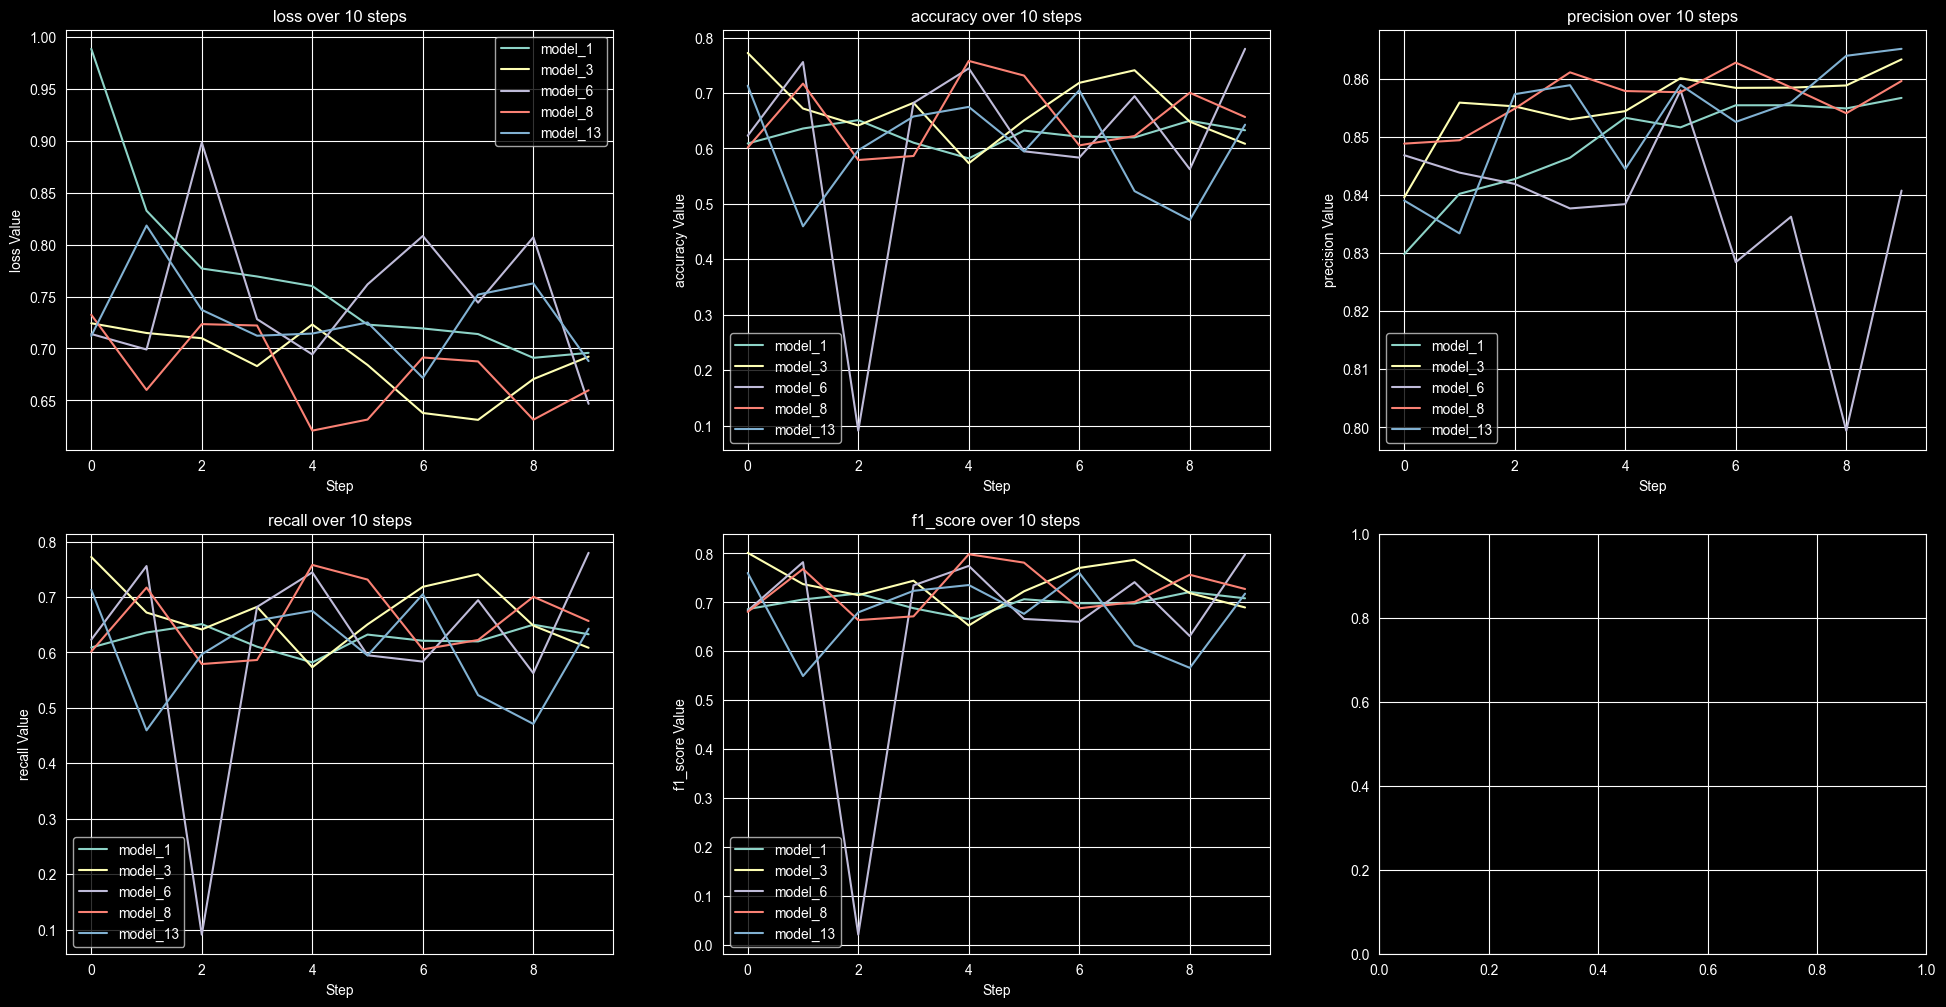

In [19]:
 best_models = train_many_models(15, [0, 1, 2], [32, 64, 128], [nn.ReLU, nn.SELU, nn.Tanh, nn.GELU], [-1, 0.2, 0.4], [1e-4, 1e-3, 1e-2], [1e-5, 1e-4], [torch.optim.RMSprop, torch.optim.Adam], is_skipping_conn=[True, False], is_batch_norm=[False, True], epochs=10, batch_sizes=[32, 64], top_models=5, metrics= {
    "accuracy" : accuracy_score,
    "precision" : precision_metric,
    "recall" : recall_metric,
    "f1_score" : f1_score_metric
}, add_weights_to_classes=True)

plot_histories("val", gather_histories(best_models))

save_best_models_info(best_models)


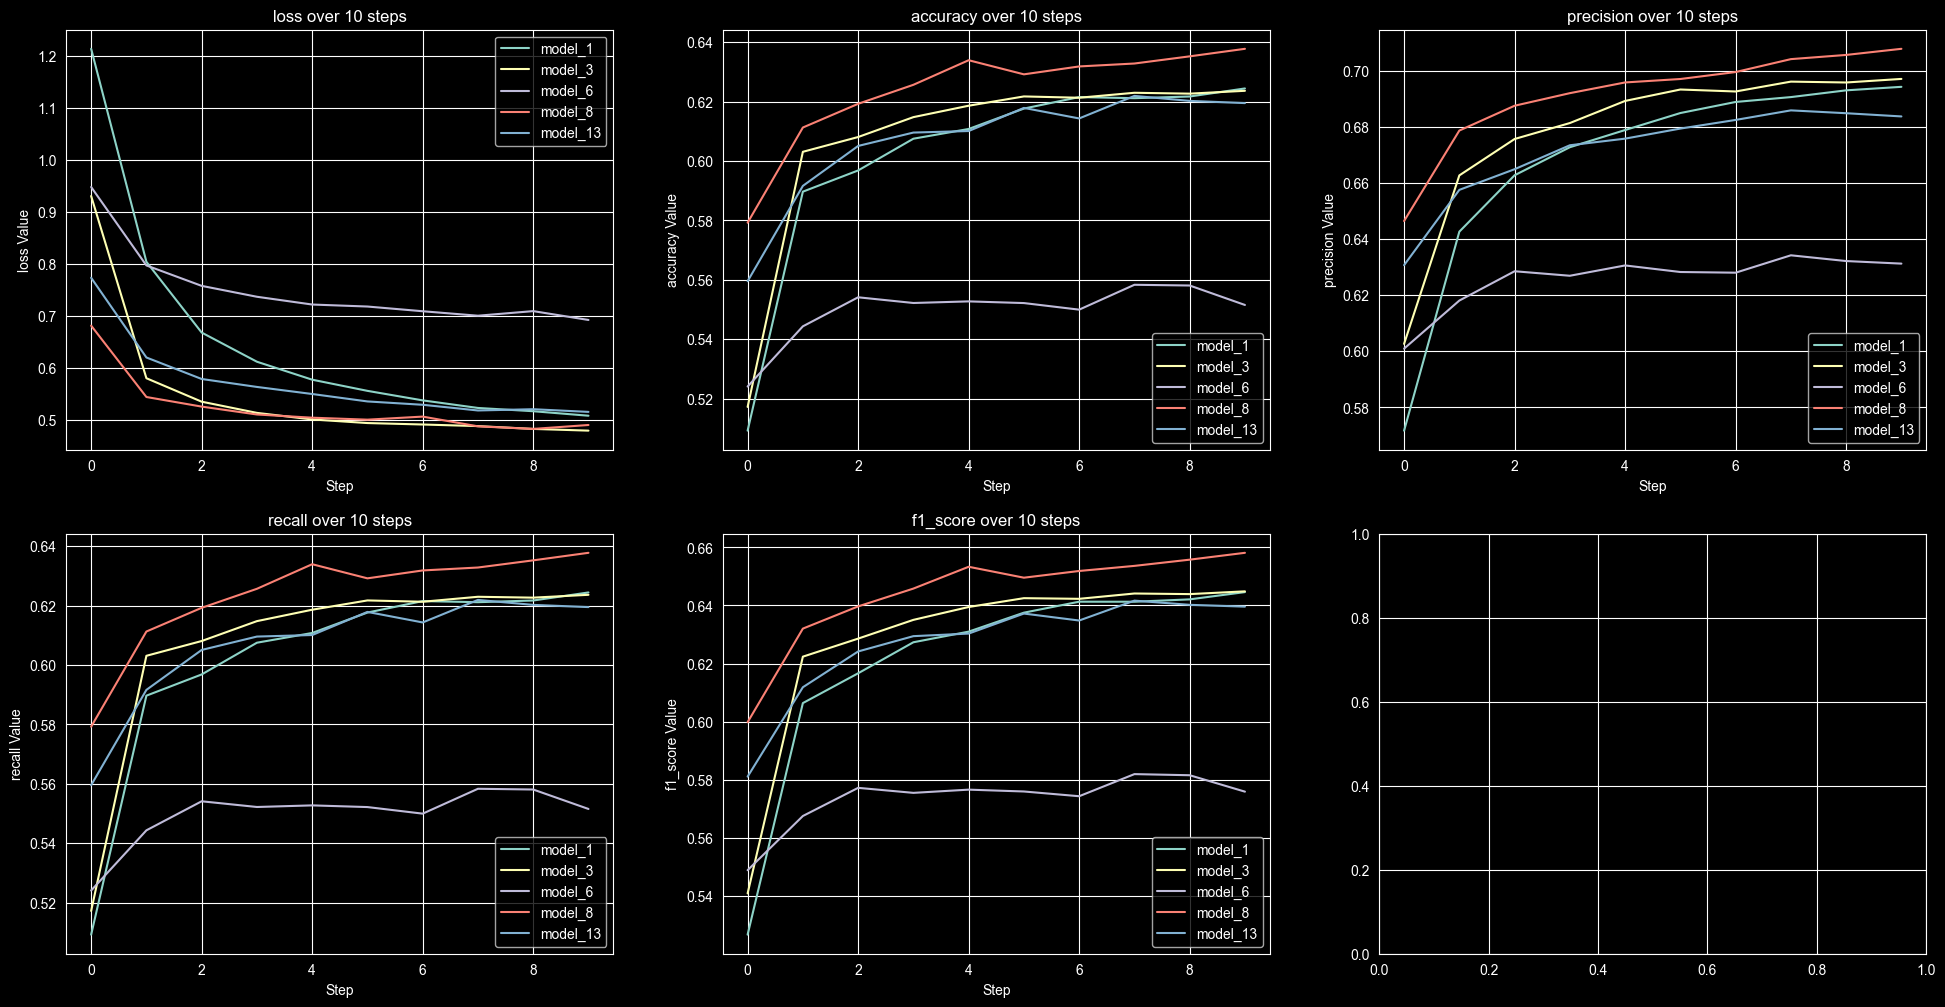

In [20]:
plot_histories("train", gather_histories(best_models))


In [21]:
class_names = dict()
with open(ROOT_PATH / "data" / "classes_info.json", 'r') as f:
     class_names = json.load(f)

class_names = [v for k, v in class_names.items()]

In [22]:
def generate_heatmap(y_true, y_pred, ax: plt.Axes | None = None, title: str = "default title", class_names: list[str]| None = None):
    conf_matrix = confusion_matrix(y_true, y_pred, normalize="true")

    if class_names is None:
        class_names = np.arange(len(conf_matrix))

    if ax is None:
        plt.figure()
        ax = plt.gca()

    sns.heatmap(conf_matrix, ax=ax, cmap="Blues", annot=True, fmt=".2f")
    ax.set_title(title)
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)


In [23]:
def plot_best_heatmaps(models: list[Model], data, criterion, device, max_img_per_width: int = 3, class_names: list[str] | None = None):
    import math
    h = math.ceil(len(models) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for i, model in enumerate(models):
        x, y = i//max_img_per_width, i%max_img_per_width
        _, y_pred, y_true = test_model(model, data, criterion, device)
        generate_heatmap(y_true, y_pred, ax=axs[x, y], title=f"Confusion matrix for model {model.name}", class_names = class_names)

    plt.tight_layout()


100%|██████████| 938/938 [00:00<00:00, 1178.19it/s]


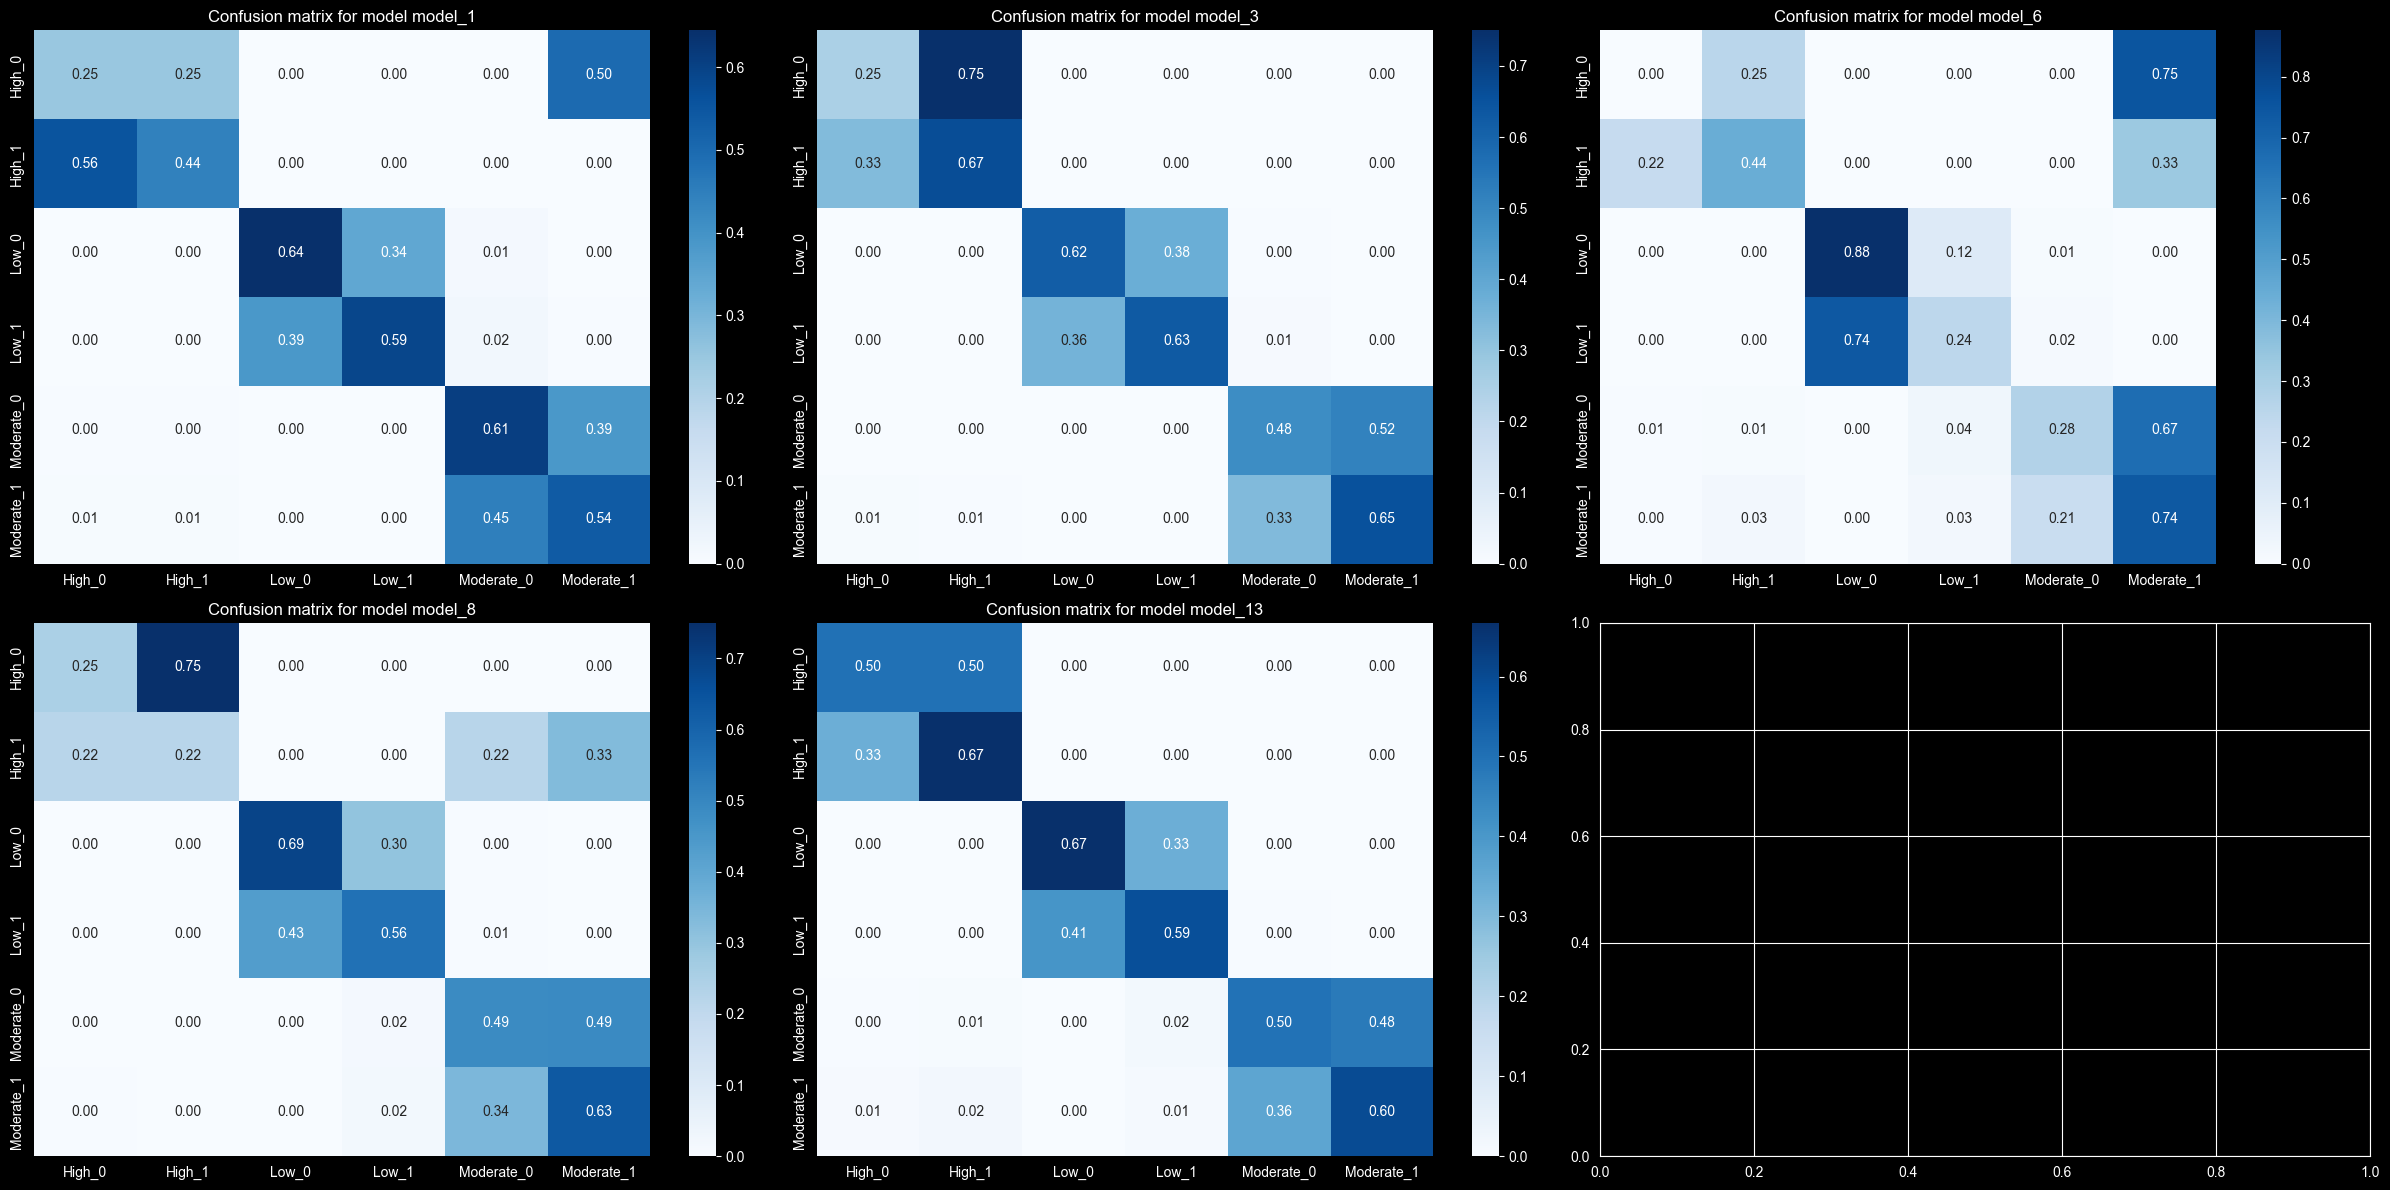

In [24]:
models_list = [model for model, _ in best_models.values()]
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False, drop_last=False)
plot_best_heatmaps(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)

In [25]:
def plot_test_metrics(y_true, y_pred, ax: plt.Axes, title:str, class_names=None):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    title += f" Global accuracy: {acc:.2%}"
    if class_names is None:
        class_names = [f"Class {i}" for i in range(len(p))]

    x = np.arange(len(class_names))
    width = 0.25

    ax.bar(x - width, p, width, label='Precision')
    ax.bar(x, r, width, label='Recall')
    ax.bar(x + width, f, width, label='F1-Score')

    ax.set_ylabel('Score (0.0 - 1.0)')
    ax.set_title(title, fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right')
    ax.set_ylim(0, 1.1)
    ax.legend(loc='upper right')


In [26]:
def plot_best_basic_scores(models: list[Model], data, criterion, device, max_img_per_width: int = 3, class_names: list[str] = None):
    import math
    h = math.ceil(len(models) / max_img_per_width)

    fig, axs = plt.subplots(h, max_img_per_width, figsize=(24, h * 6))

    for i, model in enumerate(models):
        x, y = i//max_img_per_width, i%max_img_per_width
        _, y_pred, y_true = test_model(model, data, criterion, device)
        plot_test_metrics(y_true, y_pred, ax=axs[x, y], title=f"Basic metrics for the model: {model.name}", class_names=class_names)
    plt.tight_layout()

100%|██████████| 938/938 [00:00<00:00, 1378.19it/s]


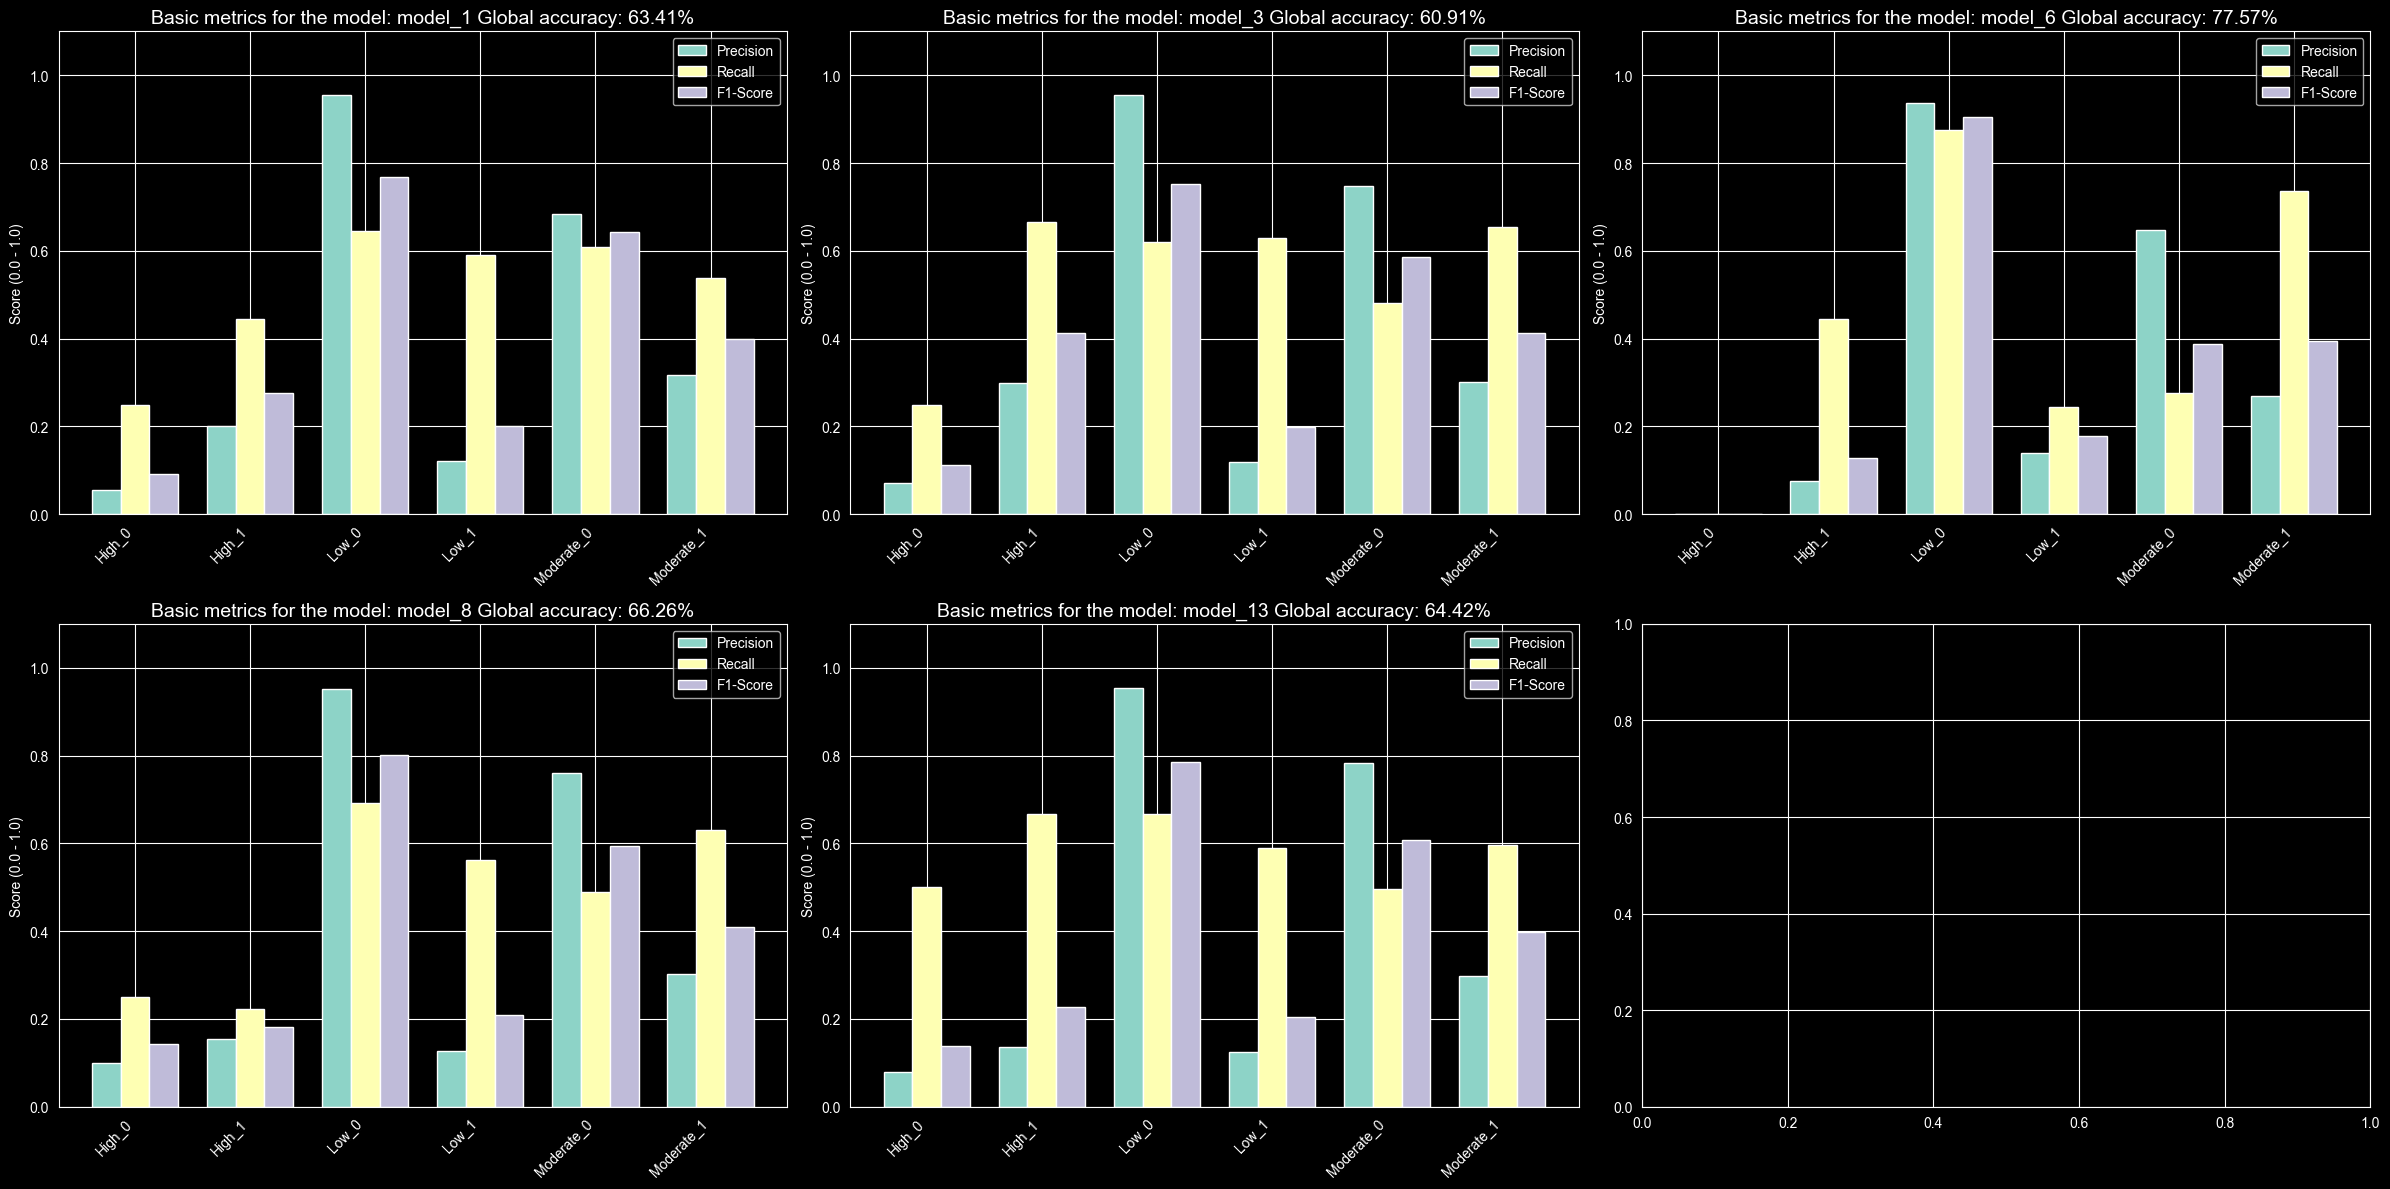

In [27]:
plot_best_basic_scores(models_list, test_loader, nn.CrossEntropyLoss(), device="cpu", class_names=class_names)